# Credit Scoring Model












## Step 1: Install & Import Libraries

In [1]:

!pip install xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.datasets import fetch_openml


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset





In [2]:

print('Loading dataset from OpenML...')
credit = fetch_openml(name='credit-g', version=1, as_frame=True)
df = credit.frame.copy()

print(f'Dataset loaded! Shape: {df.shape}')
print(f'Features : {df.shape[1] - 1}')
print(f'Samples  : {df.shape[0]}')
print()
df.head()

Loading dataset from OpenML...
Dataset loaded! Shape: (1000, 21)
Features : 20
Samples  : 1000



,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## Step 3: Exploratory Data Analysis (EDA)

In [3]:

print('Dataset Info')
print('=' * 45)
df.info()
print()
print('Statistical Summary (numeric columns):')
df.describe()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing     

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [4]:

missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing Values per Column:
No missing values found!


Target Class Distribution:
class
good    700
bad     300
Name: count, dtype: int64
   Good (creditworthy)    : 700 (70.0%)
   Bad  (not creditworthy): 300 (30.0%)


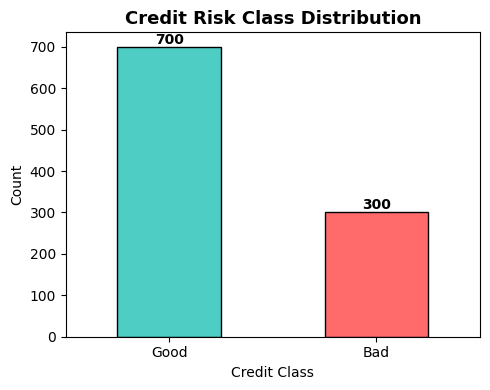

In [5]:

target_counts = df['class'].value_counts()
print('Target Class Distribution:')
print(target_counts)
print(f'   Good (creditworthy)    : {target_counts.get("good", 0)} ({target_counts.get("good", 0)/len(df)*100:.1f}%)')
print(f'   Bad  (not creditworthy): {target_counts.get("bad", 0)} ({target_counts.get("bad", 0)/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4ECDC4', '#FF6B6B']
target_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.5)
ax.set_title('Credit Risk Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Good', 'Bad'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Numeric features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


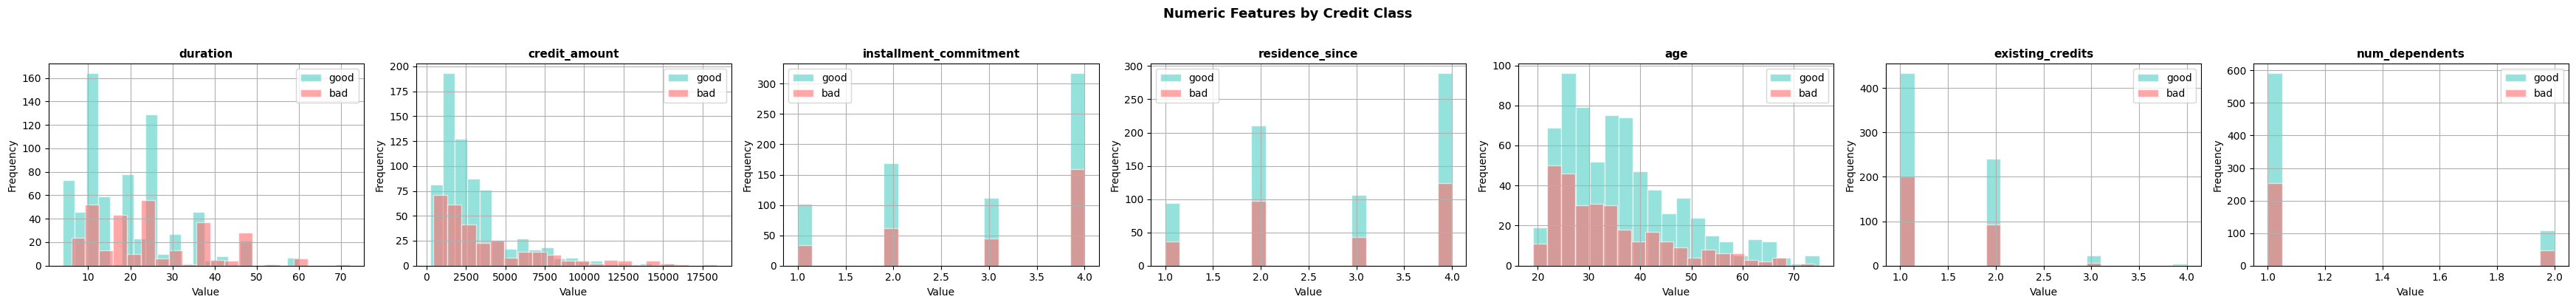

In [6]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numeric features: {numeric_cols}')

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    for cls, color in zip(['good', 'bad'], ['#4ECDC4', '#FF6B6B']):
        df[df['class'] == cls][col].hist(ax=ax, alpha=0.6, bins=20, color=color, label=cls, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Numeric Features by Credit Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

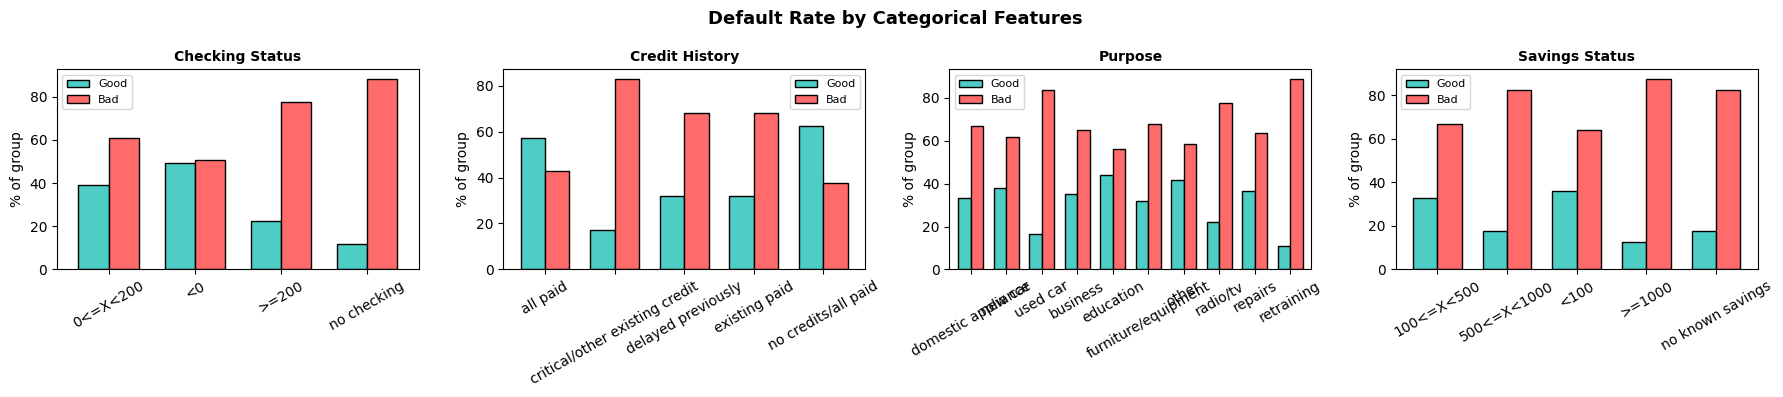

In [7]:

cat_cols = df.select_dtypes(include=['category', 'object']).columns.drop('class').tolist()
show_cols = cat_cols[:4]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, show_cols):
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4ECDC4', '#FF6B6B'], edgecolor='black', width=0.7)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% of group')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Good', 'Bad'], fontsize=8)


plt.suptitle('Default Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Feature Engineering & Preprocessing

In [8]:
X = df.drop('class', axis=1).copy()
y = df['class'].map({'good': 0, 'bad': 1})


le = LabelEncoder()
for col in X.select_dtypes(include=['category', 'object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

print('Categorical encoding complete.')
print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'Default rate  : {y.astype(int).mean()*100:.1f}%')

Categorical encoding complete.
Features shape: (1000, 20)
Target shape  : (1000,)
Default rate  : 30.0%


In [9]:

X['credit_per_duration']  = X['credit_amount'] / (X['duration'] + 1)
X['age_credit_ratio']     = X['age'] / (X['credit_amount'] + 1)
X['installment_burden']   = X['installment_commitment'] * X['credit_amount']

print('Feature engineering complete.')
print(f'New total features: {X.shape[1]}')

Feature engineering complete.
New total features: 23


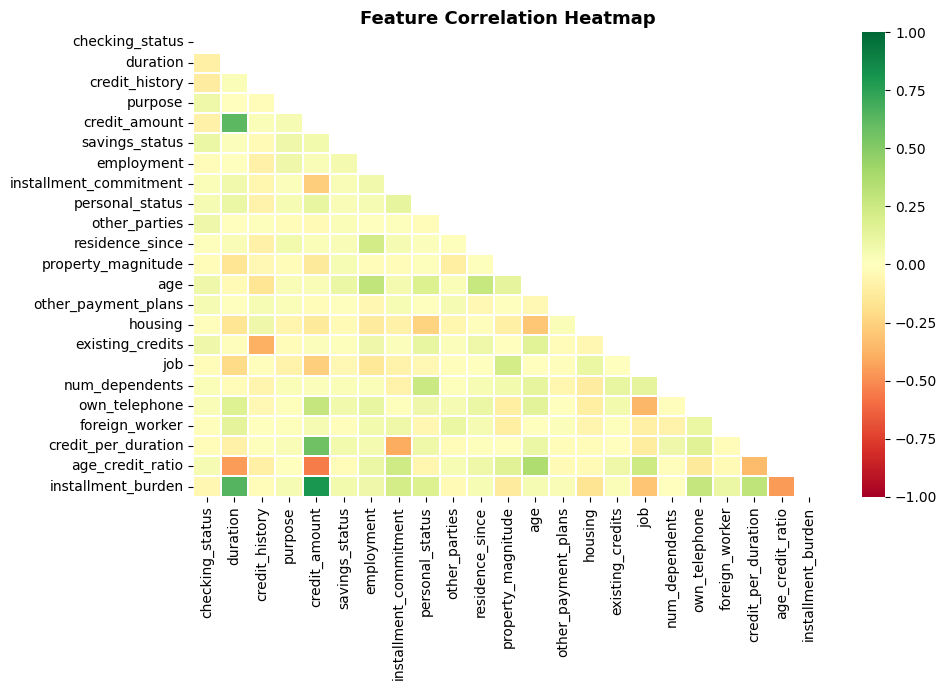

In [10]:

plt.figure(figsize=(10, 7))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            linewidths=0.3, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print('\nData split and scaled successfully!')

Training samples : 800
Testing  samples : 200

Data split and scaled successfully!


## Step 5: Train & Compare Multiple Models

In [12]:

models = {
    'Logistic Regression'    : LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Decision Tree'          : DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'XGBoost'                : XGBClassifier(n_estimators=200, learning_rate=0.05,
                                              scale_pos_weight=2, use_label_encoder=False,
                                              eval_metric='logloss', random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Model Training & Evaluation')
print('=' * 80)
print(f'{"Model":<25} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 80)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'accuracy': acc,
        'precision': prec,
        'recall'  : rec,
        'f1'      : f1,
        'roc_auc' : auc
    }

    print(f'{name:<25} {acc*100:>8.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}% {auc:>9.4f}')

print('=' * 80)

Model Training & Evaluation
Model                      Accuracy  Precision   Recall       F1   ROC-AUC
--------------------------------------------------------------------------------
Logistic Regression          66.00%     45.56%   68.33%   54.67%    0.7432
Decision Tree                61.50%     40.66%   61.67%   49.01%    0.6600
Random Forest                81.00%     84.38%   45.00%   58.70%    0.8256
Gradient Boosting            75.50%     60.38%   53.33%   56.64%    0.7815
XGBoost                      74.00%     56.06%   61.67%   58.73%    0.7907


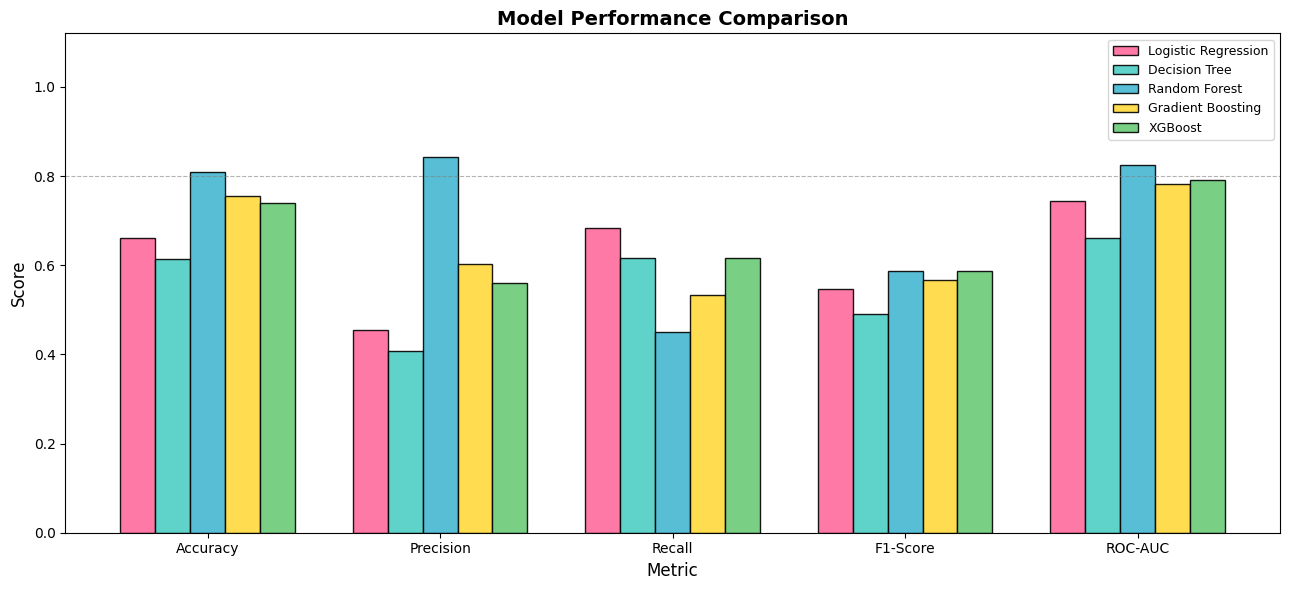

In [13]:

metrics     = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_lbls = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(results.keys())

data = np.array([[results[m][met] for met in metrics] for m in model_names])

x     = np.arange(len(metrics))
width = 0.15
colors_bar = ['#FF6B9D', '#4ECDC4', '#45B7D1', '#FFD93D', '#6BCB77']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(zip(model_names, data)):
    offset = (i - len(model_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, row, width, label=name, color=colors_bar[i], edgecolor='black', alpha=0.9)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_lbls)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 threshold')
plt.tight_layout()
plt.show()

##  Step 6: Best Model — Deep Evaluation

In [14]:

best_name = max(results, key=lambda m: results[m]['roc_auc'])
best      = results[best_name]

print(f'   Best Model : {best_name}')
print(f'   Accuracy   : {best["accuracy"]*100:.2f}%')
print(f'   Precision  : {best["precision"]*100:.2f}%')
print(f'   Recall     : {best["recall"]*100:.2f}%')
print(f'   F1-Score   : {best["f1"]*100:.2f}%')
print(f'   ROC-AUC    : {best["roc_auc"]:.4f}')
print()
print('    Full Classification Report:')
print(classification_report(y_test, best['y_pred'],
                            target_names=['Good Credit (0)', 'Bad Credit (1)']))

   Best Model : Random Forest
   Accuracy   : 81.00%
   Precision  : 84.38%
   Recall     : 45.00%
   F1-Score   : 58.70%
   ROC-AUC    : 0.8256

    Full Classification Report:
                 precision    recall  f1-score   support

Good Credit (0)       0.80      0.96      0.88       140
 Bad Credit (1)       0.84      0.45      0.59        60

       accuracy                           0.81       200
      macro avg       0.82      0.71      0.73       200
   weighted avg       0.82      0.81      0.79       200



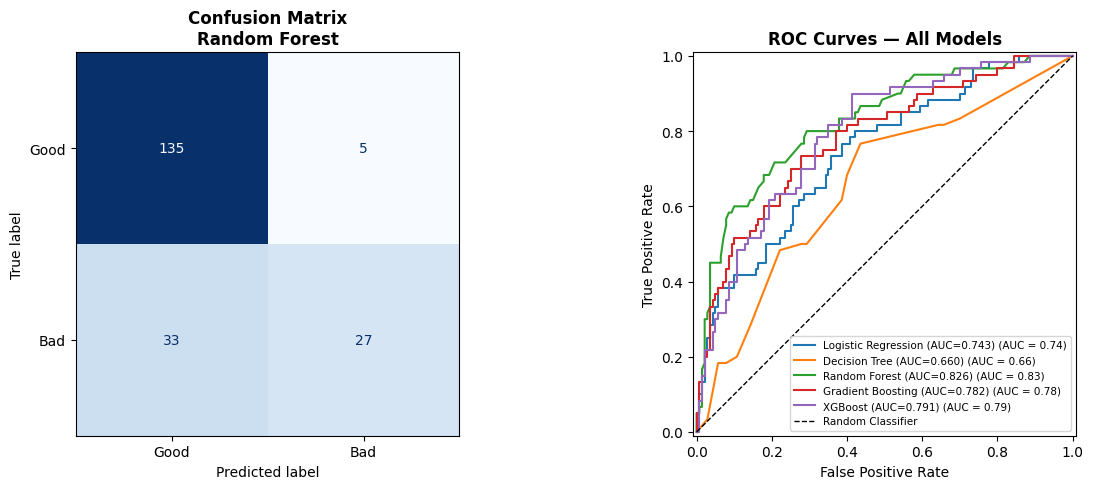

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Bad'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontsize=12, fontweight='bold')


for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=axes[1]
    )

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('ROC Curves — All Models', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=7.5, loc='lower right')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

plt.tight_layout()
plt.show()

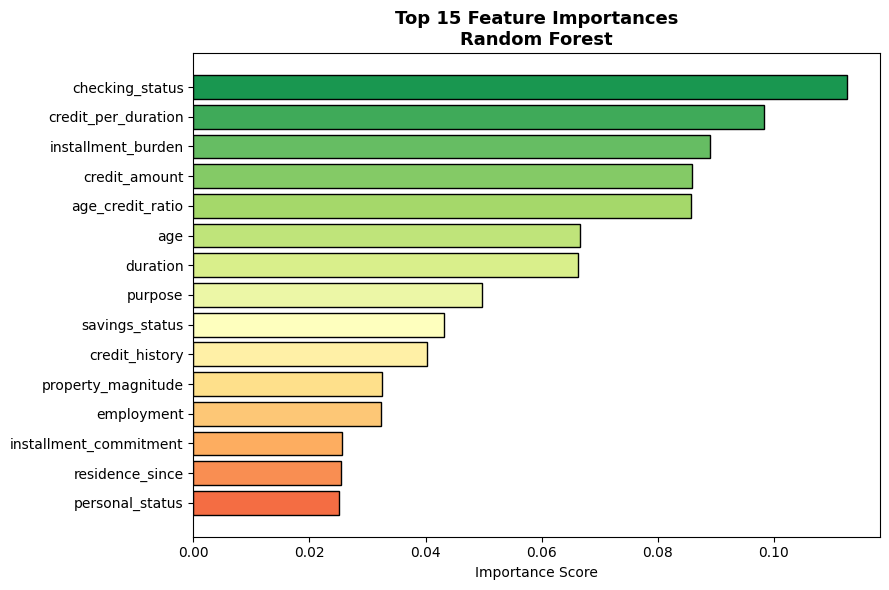

In [16]:

if hasattr(best['model'], 'feature_importances_'):
    importances = best['model'].feature_importances_
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
    ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors_imp, edgecolor='black')
    ax.set_title(f'Top 15 Feature Importances\n{best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:

    coefs = np.abs(best['model'].coef_[0])
    feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': coefs})
    feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(feat_df['Feature'], feat_df['Importance'], color='#4ECDC4', edgecolor='black')
    ax.set_title(f'Top 15 Coefficient Magnitudes\n{best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## Step 7: Credit Score Probability & Risk Tier

In [17]:

def get_risk_tier(prob_default):
    if prob_default < 0.20:
        return 'Low Risk '
    elif prob_default < 0.45:
        return 'Medium Risk '
    elif prob_default < 0.70:
        return 'High Risk '
    else:
        return 'Very High Risk '

# Apply to test set
results_df = pd.DataFrame({
    'Actual'          : y_test.map({0: 'Good', 1: 'Bad'}).values,
    'Predicted'       : pd.Series(best['y_pred']).map({0: 'Good', 1: 'Bad'}).values,
    'Default Prob (%)'  : (best['y_proba'] * 100).round(1),
    'Risk Tier'       : [get_risk_tier(p) for p in best['y_proba']]
})

print('Sample Predictions with Risk Tier:')
print(results_df.head(15).to_string(index=False))

Sample Predictions with Risk Tier:
Actual Predicted  Default Prob (%)    Risk Tier
  Good      Good              28.5 Medium Risk 
  Good      Good              18.5    Low Risk 
   Bad       Bad              51.0   High Risk 
  Good      Good              43.5 Medium Risk 
   Bad      Good              39.5 Medium Risk 
  Good      Good              29.5 Medium Risk 
  Good      Good              30.5 Medium Risk 
  Good      Good              21.0 Medium Risk 
  Good      Good              30.0 Medium Risk 
  Good      Good              35.0 Medium Risk 
  Good      Good              11.5    Low Risk 
   Bad      Good              40.5 Medium Risk 
  Good      Good               1.5    Low Risk 
   Bad      Good              36.5 Medium Risk 
   Bad       Bad              52.5   High Risk 


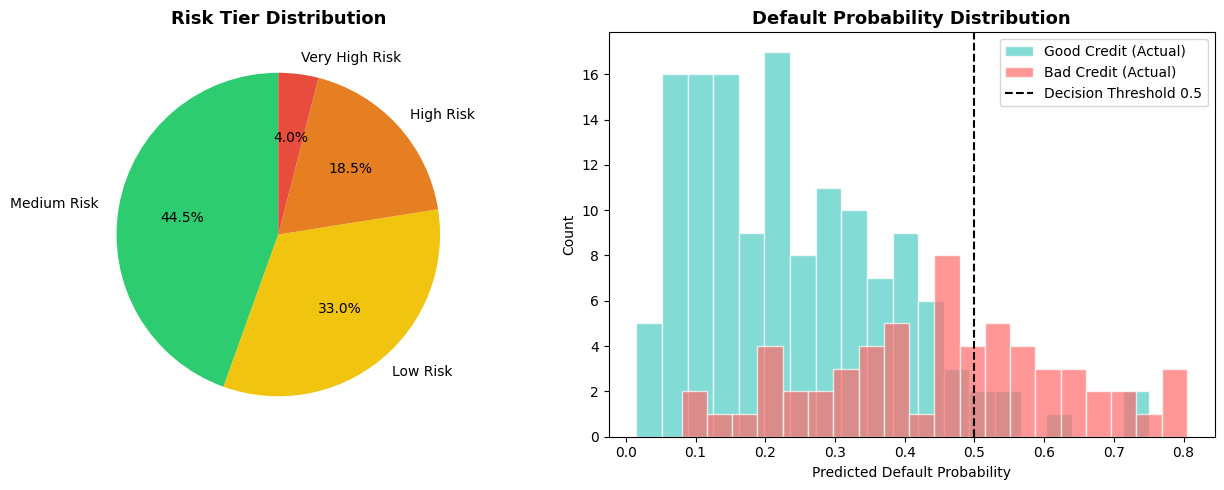

In [18]:

tier_counts = results_df['Risk Tier'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


tier_colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
tier_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                 colors=tier_colors[:len(tier_counts)], startangle=90,
                 textprops={'fontsize': 10})
axes[0].set_title('Risk Tier Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')


axes[1].hist(best['y_proba'][y_test == 0], bins=20, alpha=0.7, color='#4ECDC4',
             label='Good Credit (Actual)', edgecolor='white')
axes[1].hist(best['y_proba'][y_test == 1], bins=20, alpha=0.7, color='#FF6B6B',
             label='Bad Credit (Actual)', edgecolor='white')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold 0.5')
axes[1].set_title('Default Probability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Default Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 8: Predict for a New Individual

In [19]:



new_applicant_idx = 5

new_applicant_raw   = X_test.iloc[[new_applicant_idx]]
new_applicant_sc    = scaler.transform(new_applicant_raw)
pred_class          = best['model'].predict(new_applicant_sc)[0]
pred_proba          = best['model'].predict_proba(new_applicant_sc)[0][1]
actual_label        = y_test.iloc[new_applicant_idx]

print('=' * 55)
print('NEW APPLICANT CREDIT ASSESSMENT')
print('=' * 55)
print(f'  Model Used          : {best_name}')
print(f'  Actual Label        : {"Good Credit " if actual_label == 0 else "Bad Credit "}')
print(f'  Predicted Class     : {"Good Credit " if pred_class == 0 else "Bad Credit "}')
print(f'  Default Probability : {pred_proba*100:.1f}%')
print(f'  Risk Tier           : {get_risk_tier(pred_proba)}')
print('=' * 55)
decision = 'APPROVE LOAN' if pred_class == 0 else 'REJECT LOAN'
print(f'  Decision            : {decision}')
print('=' * 55)

NEW APPLICANT CREDIT ASSESSMENT
  Model Used          : Random Forest
  Actual Label        : Good Credit 
  Predicted Class     : Good Credit 
  Default Probability : 29.5%
  Risk Tier           : Medium Risk 
  Decision            : APPROVE LOAN


## Step 9: Final Summary

In [20]:
print('=' * 65)
print('CREDIT SCORING MODEL — FINAL SUMMARY')
print('=' * 65)
print(f'Dataset          : German Credit Data (UCI / OpenML)')
print(f'Samples          : 1,000  |  Features: {X.shape[1]}')
print(f'Train / Test     : 800 / 200  (80% / 20%)')
print(f'Preprocessing    : LabelEncoding + StandardScaler + Feature Eng.')
print(f'Models Trained   : {len(models)}')
print()
print(f'{"Model":<25} {"Accuracy":>10} {"F1":>8} {"ROC-AUC":>9}')
print('  ' + '-' * 55)
for name in results:
    marker = 'Done!' if name == best_name else '  '
    r = results[name]
    print(f'{marker} {name:<23} {r["accuracy"]*100:>9.2f}% {r["f1"]*100:>7.2f}% {r["roc_auc"]:>9.4f}')
print()
print(f'Best Model     : {best_name}')
print(f'ROC-AUC Score  : {best["roc_auc"]:.4f}')
print(f'F1-Score       : {best["f1"]*100:.2f}%')
print()
print('Key Insights:')
print('• Credit amount, duration, and checking account status are top predictors')
print('• Engineered features (credit_per_duration, installment_burden) improve AUC')
print('• Class imbalance handled with class_weight="balanced" and scale_pos_weight')
print('• ROC-AUC is the primary metric as it handles imbalance better than accuracy')
print('• Risk tiers enable graded loan decisions beyond binary approve/reject')
print('=' * 65)

CREDIT SCORING MODEL — FINAL SUMMARY
Dataset          : German Credit Data (UCI / OpenML)
Samples          : 1,000  |  Features: 23
Train / Test     : 800 / 200  (80% / 20%)
Preprocessing    : LabelEncoding + StandardScaler + Feature Eng.
Models Trained   : 5

Model                       Accuracy       F1   ROC-AUC
  -------------------------------------------------------
   Logistic Regression         66.00%   54.67%    0.7432
   Decision Tree               61.50%   49.01%    0.6600
Done! Random Forest               81.00%   58.70%    0.8256
   Gradient Boosting           75.50%   56.64%    0.7815
   XGBoost                     74.00%   58.73%    0.7907

Best Model     : Random Forest
ROC-AUC Score  : 0.8256
F1-Score       : 58.70%

Key Insights:
• Credit amount, duration, and checking account status are top predictors
• Engineered features (credit_per_duration, installment_burden) improve AUC
• Class imbalance handled with class_weight="balanced" and scale_pos_weight
• ROC-AUC is the